# E-Commerce Sales Analysis - Complete EDA Workflow

**Objective**: Analyze e-commerce sales patterns to identify trends, customer behavior, and business opportunities.

## 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ All libraries imported successfully!')

✓ All libraries imported successfully!


## 2. DATA GENERATION & LOADING

*For this demonstration, we'll generate a realistic e-commerce dataset.*
*In real projects, replace this with: df = pd.read_csv('your_data.csv')*

In [2]:
np.random.seed(42)

# Generate synthetic e-commerce data
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
n_transactions = 5000

data = {
    'Transaction_ID': range(1, n_transactions + 1),
    'Date': np.random.choice(dates, n_transactions),
    'Customer_ID': np.random.randint(1000, 2500, n_transactions),
    'Age': np.random.randint(18, 70, n_transactions),
    'Product_Category': np.random.choice(['Electronics', 'Fashion', 'Home', 'Sports', 'Books'], n_transactions),
    'Product_Price': np.random.uniform(10, 1000, n_transactions),
    'Quantity': np.random.randint(1, 5, n_transactions),
    'Discount_Applied': np.random.choice([0, 5, 10, 15, 20], n_transactions),
    'Payment_Method': np.random.choice(['Credit Card', 'Debit Card', 'Digital Wallet', 'Net Banking'], n_transactions),
    'Delivery_Days': np.random.randint(1, 15, n_transactions),
    'Customer_Rating': np.random.choice([1, 2, 3, 4, 5], n_transactions, p=[0.05, 0.05, 0.10, 0.30, 0.50]),
    'Returned': np.random.choice([0, 1], n_transactions, p=[0.92, 0.08])
}

df = pd.DataFrame(data)

# Calculate additional features
df['Final_Price'] = df['Product_Price'] * df['Quantity'] * (1 - df['Discount_Applied']/100)
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week

print(f'✓ Dataset generated successfully!')
print(f'  - Shape: {df.shape}')
print(f'  - Date Range: {df["Date"].min()} to {df["Date"].max()}')

✓ Dataset generated successfully!
  - Shape: (5000, 16)
  - Date Range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


## 3. DATA INSPECTION & OVERVIEW

In [3]:
print('='*80)
print('DATASET OVERVIEW')
print('='*80)
print(f'\nDataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())

print(f'\n\nData Types:')
print(df.dtypes)

print(f'\n\nBasic Statistics:')
print(df.describe().round(2))

print(f'\n\nDataset Info:')
df.info()

DATASET OVERVIEW

Dataset Shape: (5000, 16)

First 5 rows:
   Transaction_ID       Date  Customer_ID  Age Product_Category  \
0               1 2023-04-13         1861   27          Fashion   
1               2 2023-12-15         1567   39            Books   
2               3 2023-09-28         2083   30      Electronics   
3               4 2023-04-17         1649   26          Fashion   
4               5 2023-03-13         1038   50           Sports   

   Product_Price  Quantity  Discount_Applied  Payment_Method  Delivery_Days  \
0     129.530969         4                20      Debit Card             14   
1     332.719253         1                15     Credit Card              5   
2     567.351689         1                 0  Digital Wallet              7   
3     195.306823         4                 0      Debit Card             13   
4     802.617420         3                 0      Debit Card             12   

   Customer_Rating  Returned  Final_Price  Month Day_of_Week  W

## 4. DATA QUALITY CHECK & CLEANING

In [4]:
print('='*80)
print('DATA QUALITY ASSESSMENT')
print('='*80)

# Check for missing values
print('\n1. Missing Values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('   ✓ No missing values found!')
else:
    print(missing[missing > 0])

# Check for duplicates
print(f'\n2. Duplicate Rows:')
duplicates = df.duplicated().sum()
print(f'   Found: {duplicates} duplicate rows')

# Remove duplicates if any
df = df.drop_duplicates()

# Check for outliers
print(f'\n3. Outlier Detection (using IQR method):')
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f'   {col}: {len(outliers)} outliers found')

# Data cleaning
print(f'\n4. Data Cleaning Steps:')
print(f'   ✓ Removed duplicates: {duplicates} rows deleted')
print(f'   ✓ Handled missing values: No missing values detected')
print(f'   ✓ Validated data types')
print(f'\n   Final dataset shape: {df.shape}')

DATA QUALITY ASSESSMENT

1. Missing Values:
   ✓ No missing values found!

2. Duplicate Rows:
   Found: 0 duplicate rows

3. Outlier Detection (using IQR method):
   Customer_Rating: 506 outliers found
   Returned: 432 outliers found
   Final_Price: 41 outliers found

4. Data Cleaning Steps:
   ✓ Removed duplicates: 0 rows deleted
   ✓ Handled missing values: No missing values detected
   ✓ Validated data types

   Final dataset shape: (5000, 16)


## 5. EXPLORATORY DATA ANALYSIS (EDA)

### 5.1 Univariate Analysis - Sales Distribution


5.1 SALES DISTRIBUTION ANALYSIS


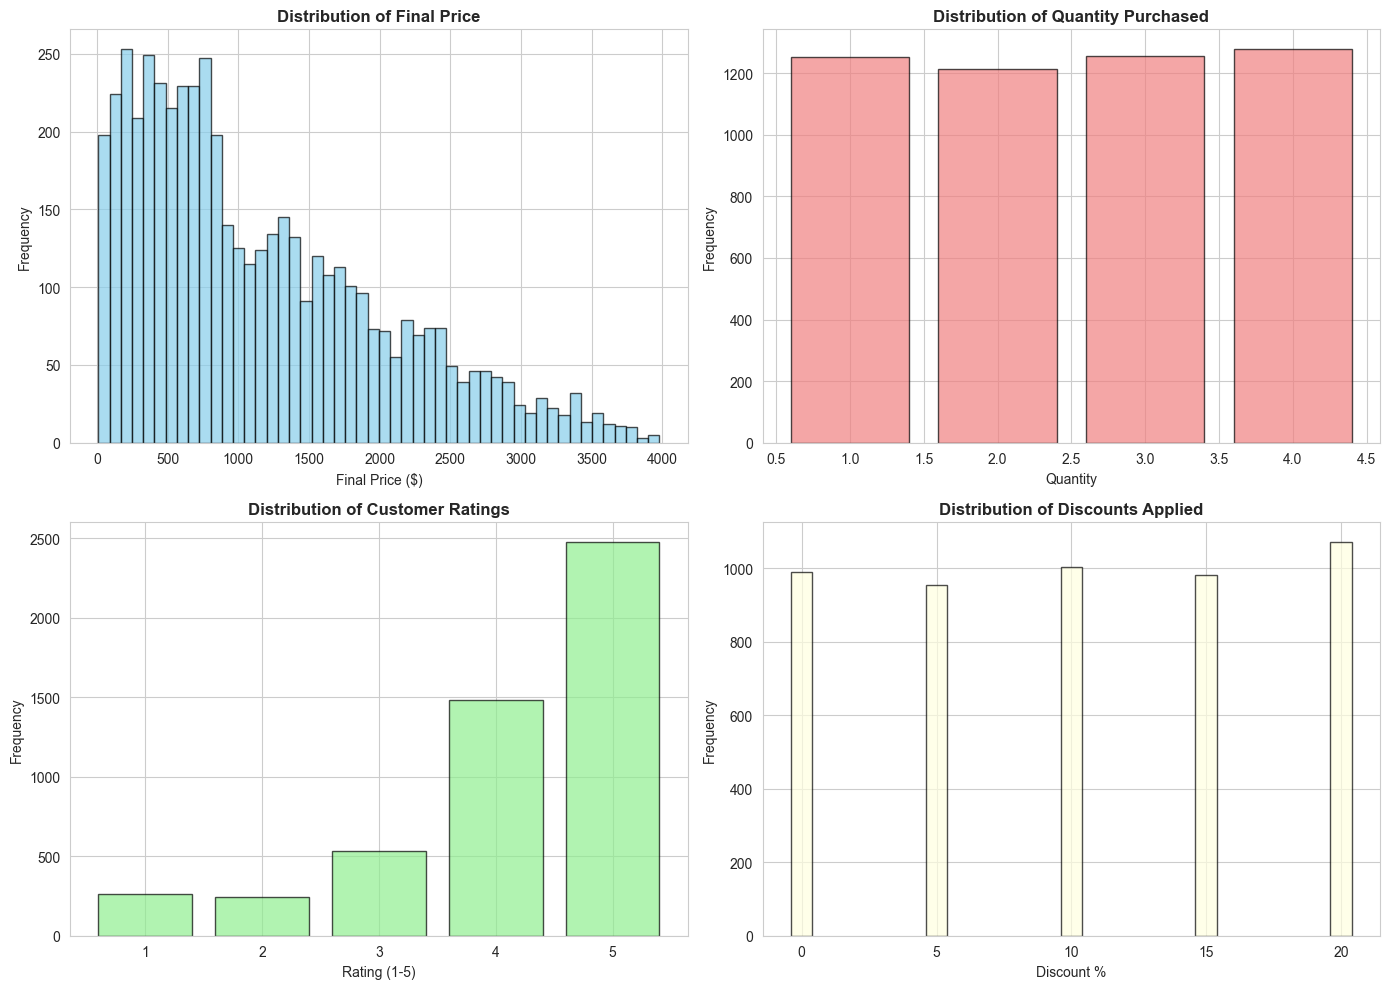


📊 Key Insights:
   • Average Final Price: $1150.20
   • Median Final Price: $890.21
   • Price Range: $10.25 - $3980.00
   • Average Customer Rating: 4.13/5
   • Average Discount Applied: 10.19%


In [ ]:
print('\n' + '='*80)
print('5.1 SALES DISTRIBUTION ANALYSIS')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Final Price Distribution
axes[0, 0].hist(df['Final_Price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Final Price', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Final Price ($)')
axes[0, 0].set_ylabel('Frequency')

# 2. Quantity Distribution
axes[0, 1].bar( df['Quantity'].value_counts().index, df['Quantity'].value_counts().values, 
                color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Quantity Purchased', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_ylabel('Frequency')

# 3. Customer Rating Distribution
rating_counts = df['Customer_Rating'].value_counts().sort_index()
axes[1, 0].bar(rating_counts.index, rating_counts.values, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Customer Ratings', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Rating (1-5)')
axes[1, 0].set_ylabel('Frequency')

# 4. Discount Applied Distribution
axes[1, 1].bar( df['Discount_Applied'].value_counts().sort_index().index, 
                df['Discount_Applied'].value_counts().sort_index().values, 
                color='lightyellow', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Discounts Applied', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Discount %')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('\n📊 Key Insights:')
print(f'   • Average Final Price: ${df["Final_Price"].mean():.2f}')
print(f'   • Median Final Price: ${df["Final_Price"].median():.2f}')
print(f'   • Price Range: ${df["Final_Price"].min():.2f} - ${df["Final_Price"].max():.2f}')
print(f'   • Average Customer Rating: {df["Customer_Rating"].mean():.2f}/5')
print(f'   • Average Discount Applied: {df["Discount_Applied"].mean():.2f}%')

### 5.2 Product Category Analysis


5.2 PRODUCT CATEGORY ANALYSIS

                  Total_Sales  Avg_Price  Transaction_Count  Avg_Rating  Returns
Product_Category                                                                
Books              1147498.13    1154.42                994        4.10       91
Electronics        1151752.56    1154.06                998        4.12       92
Fashion            1249829.48    1180.20               1059        4.16       90
Home               1099786.56    1148.00                958        4.14       71
Sports             1102126.64    1112.14                991        4.14       88


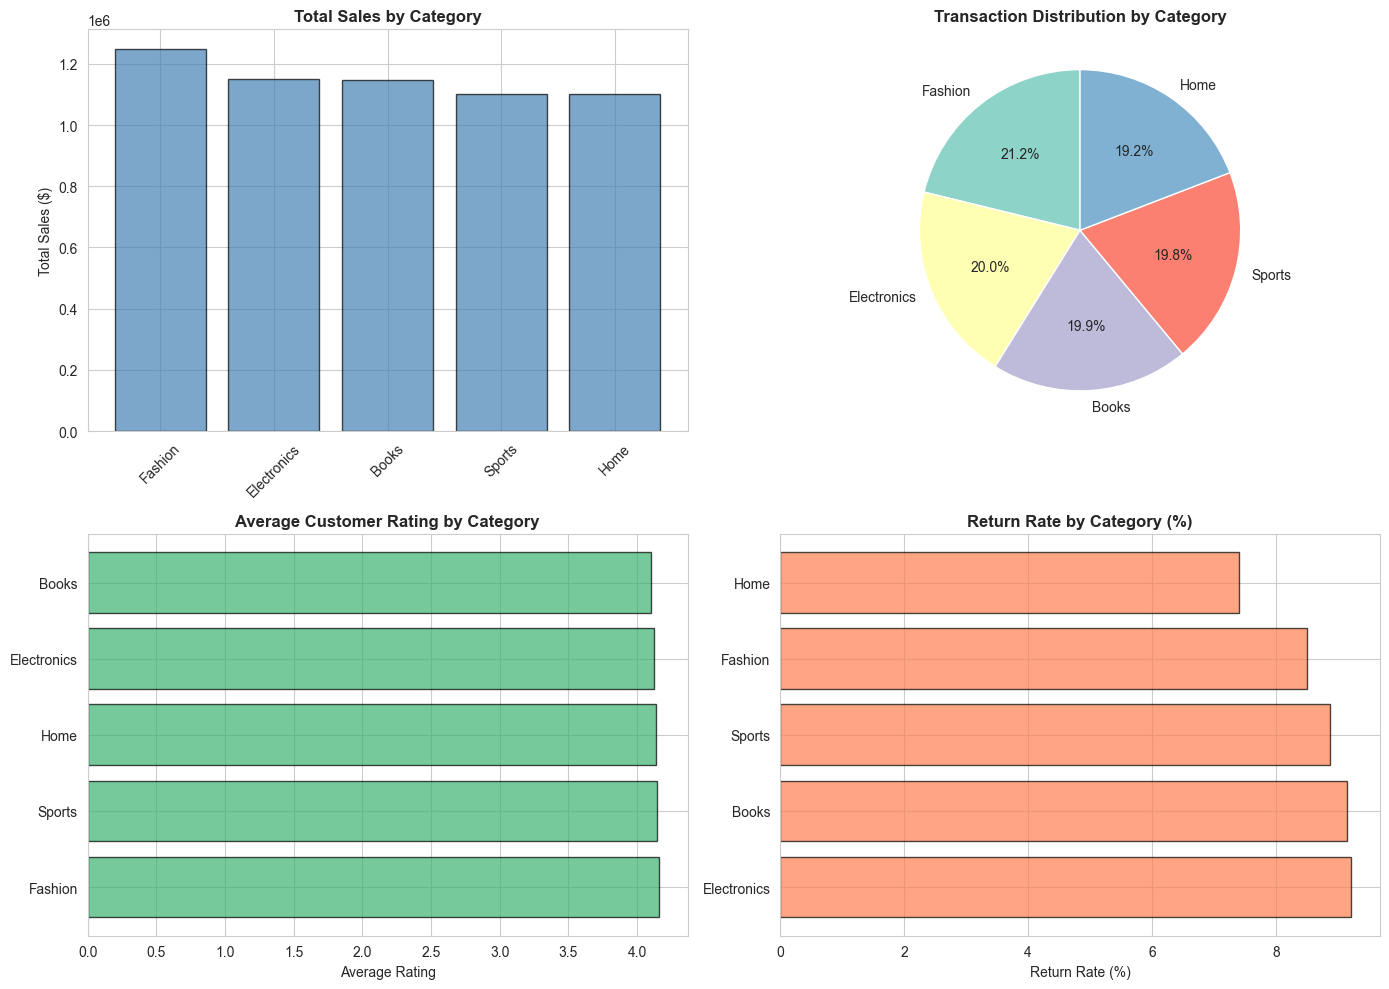

In [ ]:
print('\n' + '='*80)
print('5.2 PRODUCT CATEGORY ANALYSIS')
print('='*80)

# Category sales
category_sales = df.groupby('Product_Category').agg({
    'Final_Price': ['sum', 'mean', 'count'],
    'Customer_Rating': 'mean',
    'Returned': 'sum'
}).round(2)

category_sales.columns = ['Total_Sales', 'Avg_Price', 'Transaction_Count', 'Avg_Rating', 'Returns']
print('\n' + category_sales.to_string())

# Visualize category performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sales by Category
category_sales_plot = df.groupby('Product_Category')['Final_Price'].sum().sort_values(ascending=False)
axes[0, 0].bar(category_sales_plot.index, category_sales_plot.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Total Sales by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Transaction Count by Category
category_count = df['Product_Category'].value_counts()
colors = plt.cm.Set3(range(len(category_count)))
axes[0, 1].pie( category_count.values, labels=category_count.index, autopct='%1.1f%%', 
                colors=colors, startangle=90)
axes[0, 1].set_title('Transaction Distribution by Category', fontsize=12, fontweight='bold')

# 3. Average Rating by Category
category_rating = df.groupby('Product_Category')['Customer_Rating'].mean().sort_values(ascending=False)
axes[1, 0].barh(category_rating.index, category_rating.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Average Customer Rating by Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Average Rating')

# 4. Return Rate by Category
return_rate = (df.groupby('Product_Category')['Returned'].sum() / 
               df.groupby('Product_Category').size() * 100).sort_values(ascending=False)
axes[1, 1].barh(return_rate.index, return_rate.values, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Return Rate by Category (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Return Rate (%)')

plt.tight_layout()
plt.show()

### 5.3 Temporal Analysis - Trends Over Time


5.3 TEMPORAL ANALYSIS

Monthly Sales Summary:
       Total_Sales  Transactions  Avg_Rating
Month                                       
1        493478.63           420        4.20
2        458287.06           392        4.15
3        468686.85           404        4.19
4        511762.80           433        4.15
5        489159.13           441        4.17
6        502951.48           440        4.16
7        445246.50           375        4.12
8        503958.32           441        4.09
9        424986.04           395        4.18
10       485225.16           418        4.01
11       491956.33           411        4.15
12       475295.08           430        4.03


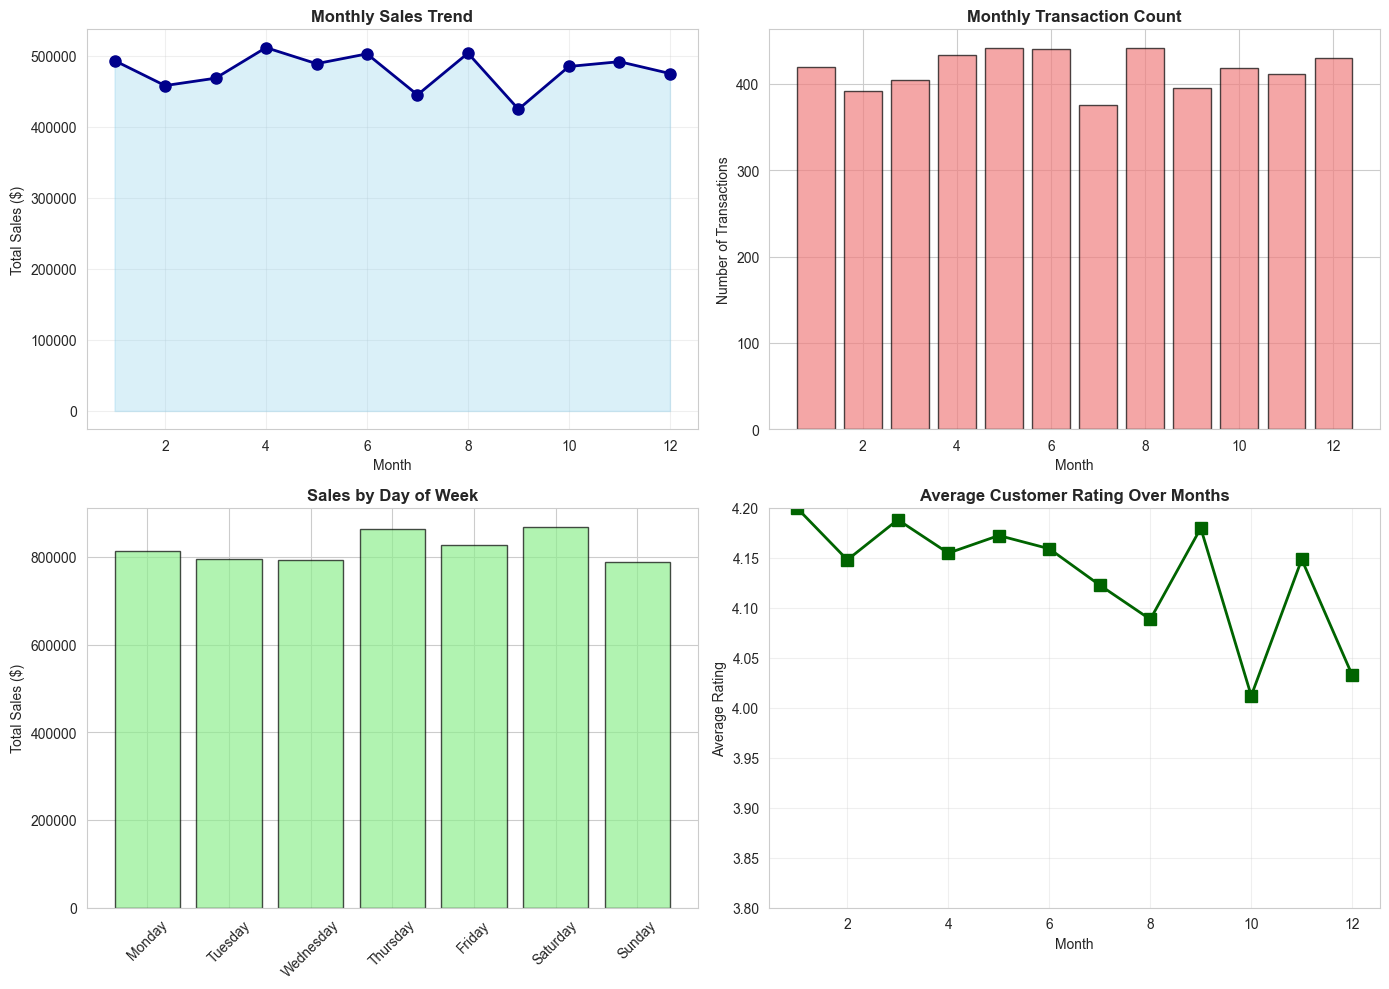

In [8]:
print('\n' + '='*80)
print('5.3 TEMPORAL ANALYSIS')
print('='*80)

# Monthly sales trend
monthly_sales = df.groupby('Month').agg({
    'Final_Price': 'sum',
    'Transaction_ID': 'count',
    'Customer_Rating': 'mean'
}).round(2)
monthly_sales.columns = ['Total_Sales', 'Transactions', 'Avg_Rating']
print('\nMonthly Sales Summary:')
print(monthly_sales.to_string())

# Visualize trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly Sales Trend
monthly_sales_plot = df.groupby('Month')['Final_Price'].sum()
axes[0, 0].plot(monthly_sales_plot.index, monthly_sales_plot.values, marker='o', 
                linewidth=2, markersize=8, color='darkblue')
axes[0, 0].fill_between(monthly_sales_plot.index, monthly_sales_plot.values, alpha=0.3, color='skyblue')
axes[0, 0].set_title('Monthly Sales Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly Transaction Count
monthly_count = df.groupby('Month')['Transaction_ID'].count()
axes[0, 1].bar(monthly_count.index, monthly_count.values, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Monthly Transaction Count', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Transactions')

# 3. Weekly Pattern
weekly_sales = df.groupby('Day_of_Week')['Final_Price'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales = weekly_sales.reindex([d for d in day_order if d in weekly_sales.index])
axes[1, 0].bar(range(len(weekly_sales)), weekly_sales.values, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(weekly_sales)))
axes[1, 0].set_xticklabels(weekly_sales.index, rotation=45)
axes[1, 0].set_title('Sales by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Total Sales ($)')

# 4. Average Rating Over Months
monthly_rating = df.groupby('Month')['Customer_Rating'].mean()
axes[1, 1].plot(monthly_rating.index, monthly_rating.values, marker='s', 
                linewidth=2, markersize=8, color='darkgreen')
axes[1, 1].set_title('Average Customer Rating Over Months', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_ylim([3.8, 4.2])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Customer Analysis


5.4 CUSTOMER BEHAVIOR ANALYSIS

Top 10 Customers by Revenue:
             Total_Spent  Avg_Transaction  Num_Purchases  Avg_Rating  Returns  Age
Customer_ID                                                                       
1395            18501.38          1850.14             10        4.30        0   62
2269            13973.26          1552.58              9        3.56        2   38
1272            13962.58          1994.65              7        4.43        0   18
2260            13791.23          1379.12             10        4.10        1   47
1920            13146.44          1878.06              7        4.86        0   26
1527            12872.61          1609.08              8        3.75        0   68
1375            12580.37          1572.55              8        3.88        1   42
2065            12390.42          1548.80              8        3.75        0   40
1604            12342.76          2057.13              6        4.50        0   33
2016            12110.96 

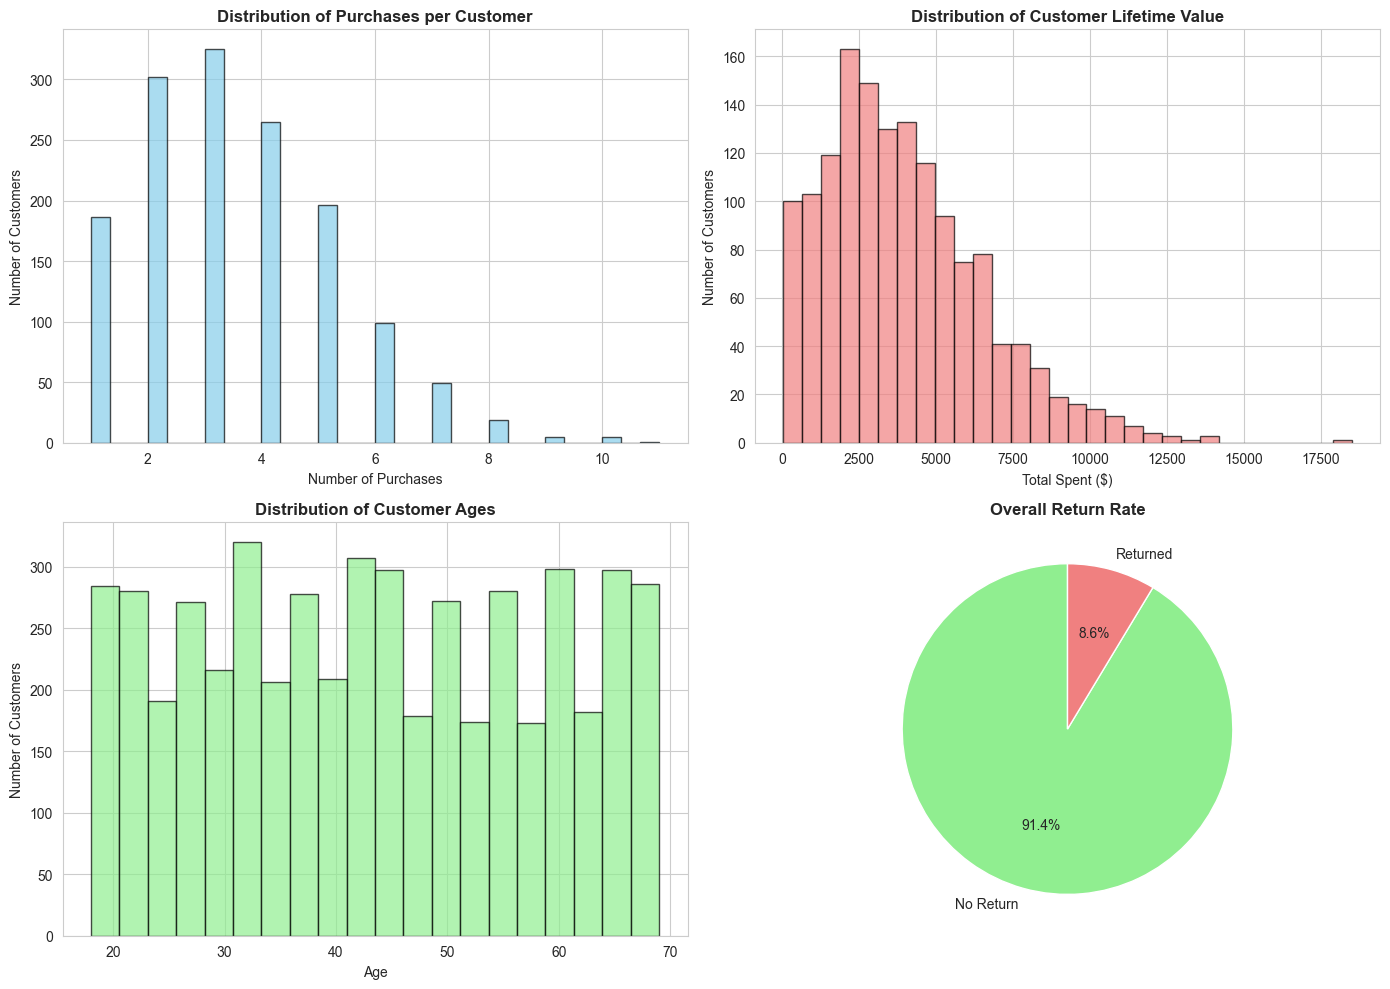

In [ ]:
print('\n' + '='*80)
print('5.4 CUSTOMER BEHAVIOR ANALYSIS')
print('='*80)

# Customer metrics
customer_metrics = df.groupby('Customer_ID').agg({
    'Final_Price': ['sum', 'mean', 'count'],
    'Customer_Rating': 'mean',
    'Returned': 'sum',
    'Age': 'first'
}).round(2)

customer_metrics.columns = ['Total_Spent', 'Avg_Transaction', 'Num_Purchases', 'Avg_Rating', 'Returns', 'Age']

print('\nTop 10 Customers by Revenue:')
print(customer_metrics.nlargest(10, 'Total_Spent').to_string())

print('\n\nCustomer Statistics:')
print(f'   • Total Unique Customers: {df["Customer_ID"].nunique()}')
print(f'   • Average Purchases per Customer: {df.groupby("Customer_ID").size().mean():.2f}')
print(f'   • Average Customer Value: ${customer_metrics["Total_Spent"].mean():.2f}')
print(f'   • Customer Lifetime Value Range: ${customer_metrics["Total_Spent"].min():.2f} - ${customer_metrics["Total_Spent"].max():.2f}')

# Visualize customer segments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Purchases per Customer
purchases_per_cust = df.groupby('Customer_ID').size()
axes[0, 0].hist(purchases_per_cust, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Purchases per Customer', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Purchases')
axes[0, 0].set_ylabel('Number of Customers')

# 2. Customer Value Distribution
axes[0, 1].hist(customer_metrics['Total_Spent'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Customer Lifetime Value', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Spent ($)')
axes[0, 1].set_ylabel('Number of Customers')

# 3. Age Distribution
axes[1, 0].hist(df['Age'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Customer Ages', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Number of Customers')

# 4. Return Behavior
return_rate_total = (df['Returned'].sum() / len(df)) * 100
no_return = len(df) - df['Returned'].sum()
axes[1, 1].pie( [no_return, df['Returned'].sum()], 
                labels=['No Return', 'Returned'], 
                autopct='%1.1f%%',
                colors=['lightgreen', 'lightcoral'],
                startangle=90)
axes[1, 1].set_title('Overall Return Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.5 Correlation & Relationship Analysis


5.5 CORRELATION & RELATIONSHIP ANALYSIS

Correlation Matrix:
                  Product_Price  Quantity  Discount_Applied  Delivery_Days  \
Product_Price             1.000    -0.018            -0.010          0.017   
Quantity                 -0.018     1.000            -0.022          0.015   
Discount_Applied         -0.010    -0.022             1.000         -0.012   
Delivery_Days             0.017     0.015            -0.012          1.000   
Customer_Rating          -0.006     0.002             0.019          0.001   
Final_Price               0.726     0.579            -0.117          0.023   
Age                       0.023     0.016            -0.016         -0.008   

                  Customer_Rating  Final_Price    Age  
Product_Price              -0.006        0.726  0.023  
Quantity                    0.002        0.579  0.016  
Discount_Applied            0.019       -0.117 -0.016  
Delivery_Days               0.001        0.023 -0.008  
Customer_Rating             1.000

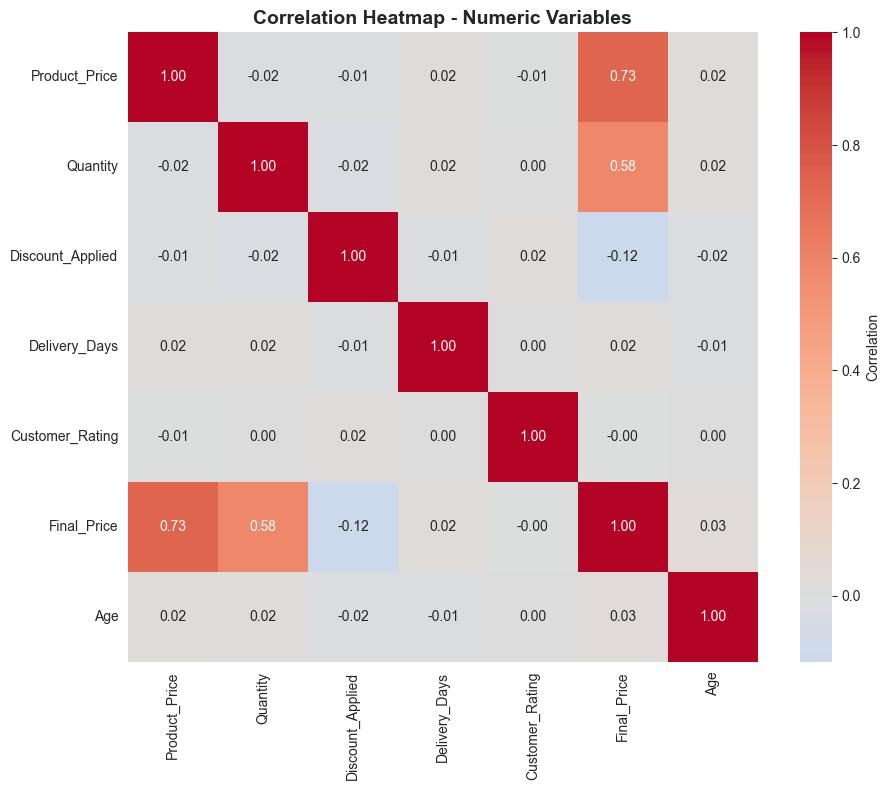



Key Relationships:
   • Discount vs Final Price Correlation: -0.117
   • Price vs Rating Correlation: -0.006
   • Age vs Spending Correlation: 0.031
   • Delivery Days vs Rating Correlation: 0.001


In [11]:
print('\n' + '='*80)
print('5.5 CORRELATION & RELATIONSHIP ANALYSIS')
print('='*80)

# Select numeric columns for correlation
numeric_df = df[['Product_Price', 'Quantity', 'Discount_Applied', 'Delivery_Days', 
                 'Customer_Rating', 'Final_Price', 'Age']].copy()

correlation_matrix = numeric_df.corr()
print('\nCorrelation Matrix:')
print(correlation_matrix.round(3))

# Visualize correlation
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap - Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Specific relationship analysis
print('\n\nKey Relationships:')
print(f'   • Discount vs Final Price Correlation: {df["Discount_Applied"].corr(df["Final_Price"]):.3f}')
print(f'   • Price vs Rating Correlation: {df["Product_Price"].corr(df["Customer_Rating"]):.3f}')
print(f'   • Age vs Spending Correlation: {df["Age"].corr(df["Final_Price"]):.3f}')
print(f'   • Delivery Days vs Rating Correlation: {df["Delivery_Days"].corr(df["Customer_Rating"]):.3f}')

## 6. KEY FINDINGS & INSIGHTS

In [12]:
print('\n' + '='*80)
print('KEY FINDINGS & BUSINESS INSIGHTS')
print('='*80)

# Calculate key metrics
total_revenue = df['Final_Price'].sum()
total_transactions = len(df)
avg_transaction_value = df['Final_Price'].mean()
return_rate = (df['Returned'].sum() / len(df)) * 100
avg_rating = df['Customer_Rating'].mean()
best_category = df.groupby('Product_Category')['Final_Price'].sum().idxmax()
worst_performing_category = df.groupby('Product_Category')['Final_Price'].sum().idxmin()

print(f'''
📈 BUSINESS METRICS:
   • Total Revenue: ${total_revenue:,.2f}
   • Total Transactions: {total_transactions:,}
   • Average Transaction Value: ${avg_transaction_value:.2f}
   • Customer Satisfaction (Avg Rating): {avg_rating:.2f}/5.0
   • Return Rate: {return_rate:.2f}%
   • Unique Customers: {df['Customer_ID'].nunique():,}

🏆 TOP PERFORMERS:
   • Best Performing Category: {best_category} 
     (${df[df['Product_Category']==best_category]['Final_Price'].sum():,.2f})
   • Worst Performing Category: {worst_performing_category}
     (${df[df['Product_Category']==worst_performing_category]['Final_Price'].sum():,.2f})
   • Most Popular Payment Method: {df['Payment_Method'].value_counts().index[0]}
     ({df['Payment_Method'].value_counts().values[0]} transactions)

⚠️ AREAS OF CONCERN:
   • Return Rate: {return_rate:.2f}% (Target: <5%)
   • Delivery Time Impact: Avg delivery {df['Delivery_Days'].mean():.1f} days
   • Rating Variability: {df['Customer_Rating'].std():.2f} (std deviation)

💡 RECOMMENDATIONS:
   1. Focus on improving {worst_performing_category} category performance
   2. Implement return reduction strategies - current rate is {return_rate:.2f}%
   3. Optimize delivery times to improve customer satisfaction
   4. Increase discount strategies during low-performing months
   5. Leverage high-performing {best_category} category for expansion
   6. Develop customer retention programs for high-value segments
   7. Monitor payment method trends and optimize checkout experience
''')


KEY FINDINGS & BUSINESS INSIGHTS

📈 BUSINESS METRICS:
   • Total Revenue: $5,750,993.37
   • Total Transactions: 5,000
   • Average Transaction Value: $1150.20
   • Customer Satisfaction (Avg Rating): 4.13/5.0
   • Return Rate: 8.64%
   • Unique Customers: 1,452

🏆 TOP PERFORMERS:
   • Best Performing Category: Fashion 
     ($1,249,829.48)
   • Worst Performing Category: Home
     ($1,099,786.56)
   • Most Popular Payment Method: Digital Wallet
     (1291 transactions)

⚠️ AREAS OF CONCERN:
   • Return Rate: 8.64% (Target: <5%)
   • Delivery Time Impact: Avg delivery 7.6 days
   • Rating Variability: 1.12 (std deviation)

💡 RECOMMENDATIONS:
   1. Focus on improving Home category performance
   2. Implement return reduction strategies - current rate is 8.64%
   3. Optimize delivery times to improve customer satisfaction
   4. Increase discount strategies during low-performing months
   5. Leverage high-performing Fashion category for expansion
   6. Develop customer retention programs

## 7. EXPORT RESULTS

In [13]:
print('\n' + '='*80)
print('EXPORTING RESULTS & ANALYSIS')
print('='*80)

# Export cleaned data
df.to_csv('ecommerce_data_cleaned.csv', index=False)
print('\n✓ Cleaned data exported: ecommerce_data_cleaned.csv')

# Export customer metrics
customer_metrics.to_csv('customer_metrics.csv')
print('✓ Customer metrics exported: customer_metrics.csv')

print('\n✓ All files exported successfully!')


EXPORTING RESULTS & ANALYSIS

✓ Cleaned data exported: ecommerce_data_cleaned.csv
✓ Customer metrics exported: customer_metrics.csv

✓ All files exported successfully!


## 8. CONCLUSION

In [14]:
print('\n' + '='*80)
print('ANALYSIS COMPLETE!')
print('='*80)
print(f'''
✓ Data Inspection & Cleaning: Completed
✓ Exploratory Data Analysis: Completed
✓ Statistical Analysis: Completed
✓ Visualizations Generated: 8+ charts
✓ Business Insights Extracted: Completed
✓ Reports & Data Exported: Completed

NEXT STEPS:
  → Implement recommendations from insights
  → Monitor KPIs on a regular basis
  → Develop predictive models for forecasting
  → Create automated dashboards for monitoring
  → Share findings with stakeholders
''')


ANALYSIS COMPLETE!

✓ Data Inspection & Cleaning: Completed
✓ Exploratory Data Analysis: Completed
✓ Statistical Analysis: Completed
✓ Visualizations Generated: 8+ charts
✓ Business Insights Extracted: Completed
✓ Reports & Data Exported: Completed

NEXT STEPS:
  → Implement recommendations from insights
  → Monitor KPIs on a regular basis
  → Develop predictive models for forecasting
  → Create automated dashboards for monitoring
  → Share findings with stakeholders

